In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from src.config import *

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

In [2]:
REGION_LIST = ['강릉', '대관령']
N_LIST = [5, 10, 15, 20, 25, 30]
CLASS_LABEL = {0: '큰 하락', 1: '하락', 2: '상승', 3: '큰 상승'}

# N_LIST 만큼 반복하여 학습된 모델의 결과을 보관하는 중첩 딕셔너리 
results = {region: {} for region in REGION_LIST}
importance_dfs = {}  # 추가 — 지역별 피처 중요도 보관

In [3]:
def load_dataset(region) -> tuple:
    """
    [입력 가공]
    region: REGION_LIST 리스트에 저장된 지역
    df = 앞 단계에서 전처리된 지역별 데이터 셋 csv

    [1차가공]
    train_df = df에서 연도가 2018년 이하인 데이터
    test_df = df에서 연도가 2019년 이상인 데이터

    [2차가공]
    - date, price_change_rate, target 컬럼을 feature에서 제외
    - target 컬럼을 y_train, y_test로 분리
    - 결과적으로 X_train, X_test는 모델 입력용 feature 데이터
    - y_train, y_test는 정답 레이블 데이터

    [출력]
    X_train, X_test: 모델 입력용 feature DataFrame
    y_train, y_test: target 레이블 Series
    """
    df = pd.read_csv('processed/dataset_' + region + '.csv')
    df['date'] = pd.to_datetime(df['date'])

    train = df[df['date'].dt.year <= 2018]
    test = df[df['date'].dt.year >= 2019]

    print(f"\n{'='*40}")
    print(f"  [{region}] 데이터셋 로드")
    print(f"{'='*40}")
    print(f"학습: {len(train)}행, 테스트: {len(test)}행")

    nan_train = train.isnull().sum()
    nan_test = test.isnull().sum()

    print(f"\n[train NaN] {'없음' if not nan_train.any() else ''}")
    if nan_train.any():
        print(nan_train[nan_train > 0])

    print(f"\n[test NaN] {'없음' if not nan_test.any() else ''}")
    if nan_test.any():
        print(nan_test[nan_test > 0])

    # 전처리
    # 현재 데이터 프레임에서 date와 price_change_rate 컬럼을 제외시키기
    exclude_cols = ['date', 'price_change_rate']
    target_col = 'target'

    # 학습용 데이터와 테스트용 데이터를 분리
    X_train = train.drop(columns=exclude_cols + [target_col])
    X_test = test.drop(columns=exclude_cols + [target_col])
    y_train = train[target_col]
    y_test = test[target_col]

    return X_train, X_test, y_train, y_test

In [4]:
def scale_for_svm(X_train, X_test):
    # MinMaxScaler는 SVM 모델에만 사용한다.
    # SVM은 데이터 포인트 간 거리를 기반으로 경계를 찾고, 피처 값의 단위가 다르면 거리 계산이 왜곡된다.
    print(f"[X_train]", X_train.isnull().sum())
    print(f"[X_test]", X_test.isnull().sum())

    scaler = MinMaxScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"[scale_for_svm] X_test_scaled NaN 존재 여부: ", np.sum(np.isnan(X_test_scaled))) # 52건의 NaN 데이터

    return X_train_scaled, X_test_scaled, scaler

In [5]:
def train_svm(X_train_scaled, y_train):
    model = SVC(kernel='rbf', random_state=42)

    # 모델 학습
    model.fit(X_train_scaled, y_train)

    # 학습된 모델 반환
    return model

In [6]:
# Random_Forest은 트리들이 독립적으로 학습 -> 결과를 투표로 합산
# 작동 예시: [트리1] [트리2] [트리3] -> 다수결
# 그렇기 때문에 Random_Forest는 병렬처리가 가능하다.
def train_random_forest(X_train, y_train):
    param_grid = {
        "n_estimators": [15, 20, 25, 30],
        "max_depth": [3, 4, 5]
    }

    # 최적화
    grid_search_for_rfc = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    # 모델 학습
    grid_search_for_rfc.fit(X_train, y_train)

    print(f"[RandomForest] 최적 파라미터: {grid_search_for_rfc.best_params_}")
    print(f"[RandomForest] 교차검증 정확도: {grid_search_for_rfc.best_score_:.4f}")

    # 학습된 모델 반환
    return grid_search_for_rfc.best_estimator_

In [7]:
# Gradient_Boosting은 트리들을 순서대로 학습 -> 앞 트리의 실수를 다음 트리가 보정
# 작동 예시: [트리1] -> 오류 -> [트리2] -> 오류 -> [트리3] -> 최종 합산
# 그렇기 때문에 Gradient_Boosting은 병렬처리가 안된다.
def train_gradient_boosting(X_train, y_train):
    param_grid = {
        "n_estimators": [4, 5, 8],
        "max_depth": [2, 3, 4, 5]
    }

    grid_search_for_gb = GridSearchCV(
        GradientBoostingClassifier(random_state=42),
        param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    # 모델 학습
    grid_search_for_gb.fit(X_train, y_train)

    print(f"[GradientBoosting] 최적 파라미터: {grid_search_for_gb.best_params_}")
    print(f"[GradientBoosting] 교차검증 정확도: {grid_search_for_gb.best_score_:.4f}")

    return grid_search_for_gb.best_estimator_

In [8]:
def extract_feature_importance(rf_model, gb_model, X_train) -> pd.DataFrame:
    # 파라미터로 학습이 완료된 모델 객체를 받아서 데이터프레임으로 변환하는데
    rf_importance_df = pd.DataFrame({
        'feature': X_train.columns,
        'rf_importance': rf_model.feature_importances_
    }).sort_values('rf_importance', ascending=False)

    rf_importance_df['rf_rank'] = range(1, len(rf_importance_df) + 1)

    gb_model_df = pd.DataFrame({
        'feature': X_train.columns,
        'gb_importance': gb_model.feature_importances_
    }).sort_values('gb_importance', ascending=False)

    gb_model_df['gb_rank'] = range(1, len(gb_model_df) + 1)

    # 새로운 구조의 DataFrame을 만들어 반환한다.
    # feature, rf_importance, gb_importance, rf_rank, gb_rank 순으로 출력해야한다.
    # feature이름을 기준으로 left outer join을 하자

    result_df = pd.merge(rf_importance_df, gb_model_df, on='feature', how='outer')

    # 원하는 순서로 출력하기 위해 변경
    result_df = result_df[['feature', 'rf_importance', 'gb_importance', 'rf_rank', 'gb_rank']]

    return result_df
    

In [9]:
def get_top_features(importance_df, model_name, top_n) -> list:
    # 출력으로 상위 n개 피처 이름 리스트
    # 내림차순으로 정렬된 데이터프레임이 반환되는데, 이걸 rank 기준으로 정렬해야 상위 N개가 올바르게 나올 거 같음
    
    if model_name == 'RF':
        sorted_df = importance_df.sort_values('rf_rank', ascending=True).head(top_n)
        return sorted_df['feature'].tolist()
    else:
        sorted_df = importance_df.sort_values('gb_rank', ascending=True).head(top_n)
        return sorted_df['feature'].tolist()

In [10]:
def evaluate_model(model, X_test, y_test, model_name):
    print(f"\n{'='*40}")
    print(f"  {model_name}")
    print(f"{'='*40}")
    # y_test 값은 실제 정답값
    # 예측값 생성
    y_pred = model.predict(X_test)

    # 정확도 출력
    acc = accuracy_score(y_test, y_pred)
    print(f"[{model_name}] Accuracy: {acc:.4f}")

    # 리포트 출력
    print(f"[{model_name}] Classification Report:")
    print(classification_report(y_test, y_pred))

    # 혼동 행렬 출력
    print(f"[{model_name}] Confusion_Matrix")
    print(confusion_matrix(y_test, y_pred))

    return acc

In [11]:
for region in REGION_LIST:
    # 1. load_dataset()
    X_train, X_test, y_train, y_test = load_dataset(region)

    # 2. RF/GB 42개 피처로 학습
    rf_model = train_random_forest(X_train, y_train)
    gb_model = train_gradient_boosting(X_train, y_train)

    # 3. extranct_featrue_importance() -> importance_df
    importance_df = extract_feature_importance(rf_model, gb_model, X_train)
    importance_dfs[region] = importance_df

    # 4. N_LIST 루프
    for N in N_LIST:
        # 4.1 get_top_feature()로 상위 N개 피처 이름 추출
        rf_feature_list_cols = get_top_features(importance_df, "RF", N)
        gb_feature_list_cols = get_top_features(importance_df, "GB", N)
        
        # 4.2 X_train, X_test에서 해당 컬럼만 선택
        # 현재 X_train은 42개 컬럼을 가진 DF인데, N = 5일 때, get_top_feature()가 반환하는건 5개의 피처이고, 이걸 기반으로 모델을 재학습시켜야한다는 말이다.
        rf_selected_train_df = X_train[rf_feature_list_cols]
        rf_selected_test_df = X_test[rf_feature_list_cols]

        gb_selected_train_df = X_train[gb_feature_list_cols]
        gb_selected_test_df = X_test[gb_feature_list_cols]

        # 4.3 RF/GB/SVM 재학습 + evaluate_model()
        # rf
        rf_model = train_random_forest(rf_selected_train_df, y_train)
        rf_acc = evaluate_model(rf_model, rf_selected_test_df, y_test, "RANDOM FOREST")
        # gb
        gb_model = train_gradient_boosting(gb_selected_train_df, y_train)
        gb_acc = evaluate_model(gb_model, gb_selected_test_df, y_test, "GRADIENT BOOSTING")

        # SVM
        # X_train_scaled = scaler.fit_transform(X_train)
        # X_test_scaled = scaler.transform(X_test)
        X_train_scaled, X_test_scaled, _ = scale_for_svm(rf_selected_train_df, rf_selected_test_df)
        svm_model = train_svm(X_train_scaled, y_train)
        svm_acc = evaluate_model(svm_model, X_test_scaled, y_test, "SVM_MODEL")

        # 정확도 기록
        results[region][N] = {'RF': rf_acc, 'GB': gb_acc, 'SVM': svm_acc}


  [강릉] 데이터셋 로드
학습: 1476행, 테스트: 861행

[train NaN] 없음

[test NaN] 없음
[RandomForest] 최적 파라미터: {'max_depth': 3, 'n_estimators': 15}
[RandomForest] 교차검증 정확도: 0.2825
[GradientBoosting] 최적 파라미터: {'max_depth': 2, 'n_estimators': 5}
[GradientBoosting] 교차검증 정확도: 0.3089
[RandomForest] 최적 파라미터: {'max_depth': 3, 'n_estimators': 15}
[RandomForest] 교차검증 정확도: 0.2994

  RANDOM FOREST
[RANDOM FOREST] Accuracy: 0.2451
[RANDOM FOREST] Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.22      0.26       256
           1       0.12      0.06      0.08       152
           2       0.20      0.44      0.28       189
           3       0.33      0.23      0.27       264

    accuracy                           0.25       861
   macro avg       0.24      0.24      0.22       861
weighted avg       0.26      0.25      0.24       861

[RANDOM FOREST] Confusion_Matrix
[[ 56  20 131  49]
 [ 21   9 101  21]
 [ 33  16  84  56]
 [ 70  33  99  62]]
[GradientBoo

  region   N        RF        GB       SVM
0     강릉   5  0.245064  0.203252  0.259001
1     강릉  10  0.326365  0.268293  0.293844
2     강릉  15  0.301974  0.268293  0.318235
3     강릉  20  0.324042  0.248548  0.315912
4     강릉  25  0.283391  0.245064  0.303136
5     강릉  30  0.295006  0.249710  0.299652


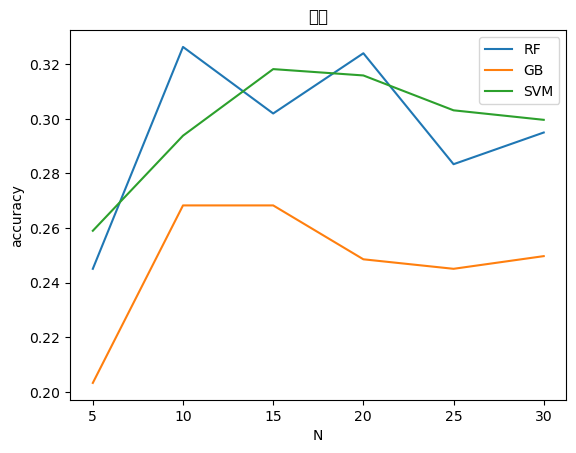

  region   N        RF        GB       SVM
0    대관령   5  0.229965  0.176539  0.256678
1    대관령  10  0.222997  0.243902  0.257840
2    대관령  15  0.225319  0.246225  0.236934
3    대관령  20  0.216028  0.243902  0.285714
4    대관령  25  0.238095  0.261324  0.298490
5    대관령  30  0.261324  0.229965  0.333333


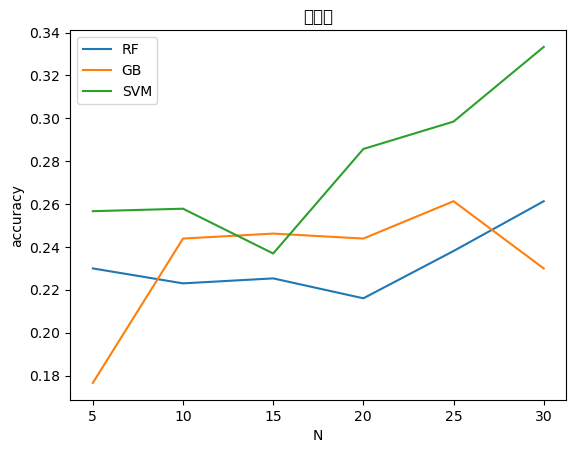

In [12]:
for region, n_dict in results.items():
    # results 기반으로 비교표 출력 + 그래프
    # 지역별로 결과를 데이터프레임 형태로 반환해야한다.
    rows = []
    for top_n, model_dict in n_dict.items():
        rows.append({
            'region': region,
            'N': top_n,
            'RF': model_dict['RF'],
            'GB': model_dict['GB'],
            'SVM': model_dict['SVM']
        })
        
    df = pd.DataFrame(rows)
    print(df)


    # rows를 기반으로 시각화를 하면 되는데
    # 꺾은선 그래프를 그릴거고 x축은 N, y축은 정확도 선은 3개, region별로 subplot 또는 별도의 그래프로 전환한다.

    x = df['N']
    y_rf = df['RF']
    y_gb = df['GB']
    y_svm = df['SVM']

    plt.plot(x, y_rf, label="RF")
    plt.plot(x, y_gb, label="GB")
    plt.plot(x, y_svm, label="SVM")

    plt.xlabel("N")
    plt.ylabel("accuracy")
    plt.title(f"{region}")
    plt.legend()
    plt.show()


In [13]:
def plot_feature_importance(model, X_train, model_name, top_n=20):
    # SVM 모델은 fit_transform()은 numpy array를 반환하기에, 컬럼명이 보존되지 않는다.
    # 반면, RFC/GB는 X_train은 그대로 사용하기 때문에 컬럼명이 보존되어 있어 model.feature_importances_와 바로 매칭 가능
    importance_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    

    # 상위 N개만 선택
    top_importance_df = importance_df.head(top_n).sort_values('importance', ascending=True)

    # 막대그래프로 시각화 (seaborn 또는 matplotlib)
    plt.barh(top_importance_df["feature"], top_importance_df["importance"])
    plt.title(f"[{model_name}] Top {top_n} Feature Importance")
    plt.xlabel("Importance")   # 추가
    plt.tight_layout()         # 레이블 잘림 방지
    plt.show()

In [14]:
def show_year_results(model, region, year, model_name, feature_cols=None, scaler=None):
    df = pd.read_csv('processed/dataset_' + region + '.csv')
    df['date'] = pd.to_datetime(df['date'])

    target_df = df[df['date'].dt.year == year].copy()
    if target_df.empty:
        print(f'[{region}] {year}년 데이터 없음')
        return

    exclude_cols = ['date', 'price_change_rate']
    target_col = 'target'
    X = target_df.drop(columns=exclude_cols + [target_col])

    if feature_cols is not None:
        X = X[feature_cols]

    if scaler is not None:
        X = scaler.transform(X)

    target_df['예측'] = model.predict(X)
    target_df['정답'] = target_df[target_col].map(CLASS_LABEL)
    target_df['예측값'] = target_df['예측'].map(CLASS_LABEL)
    target_df['일치'] = target_df[target_col] == target_df['예측']

    result = target_df[['date', '정답', '예측값', '일치']].reset_index(drop=True)

    print(f"\n{'='*50}")
    print(f"  [{region}] {year}년 출하일별 가격 변동 구간 예측 ({model_name})")
    print(f"{'='*50}")
    print(result.to_string(index=False))
    acc = target_df['일치'].mean()
    print(f"\n{year}년 정확도: {acc:.4f} ({int(target_df['일치'].sum())}/{len(target_df)}일 일치)")


  [강릉] 데이터셋 로드
학습: 1476행, 테스트: 861행

[train NaN] 없음

[test NaN] 없음

[강릉] 최적 N — RF: 10, GB: 10, SVM: 15
[RandomForest] 최적 파라미터: {'max_depth': 3, 'n_estimators': 15}
[RandomForest] 교차검증 정확도: 0.3062
[GradientBoosting] 최적 파라미터: {'max_depth': 2, 'n_estimators': 4}
[GradientBoosting] 교차검증 정확도: 0.3360
[X_train] Planting_SPI4                     0
Planting_avg_dew_point_temp       0
Planting_min_grass_temp           0
Growing_Total_solar_radiation     0
Planting_min_relative_humidity    0
Planting_Total_solar_radiation    0
Planting_max_temp                 0
Planting_avg_temp                 0
Planting_SPI2                     0
Planting_avg_ground_temp          0
Planting_SPI3                     0
Sowing_min_temp                   0
Growing_min_relative_humidity     0
Growing_SPI4                      0
Planting_avg_relative_humidity    0
dtype: int64
[X_test] Planting_SPI4                     0
Planting_avg_dew_point_temp       0
Planting_min_grass_temp           0
Growing_Total_solar_ra

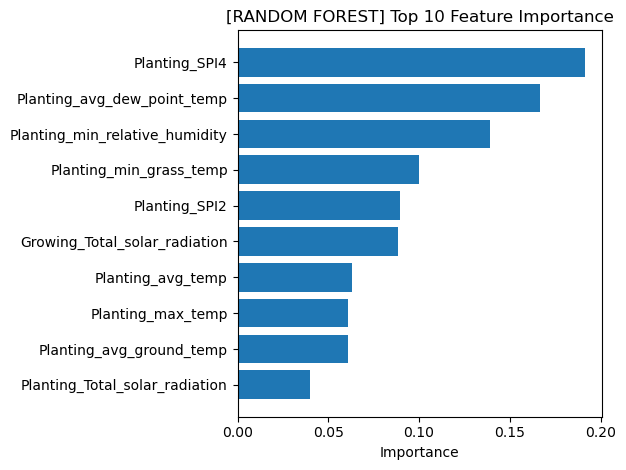

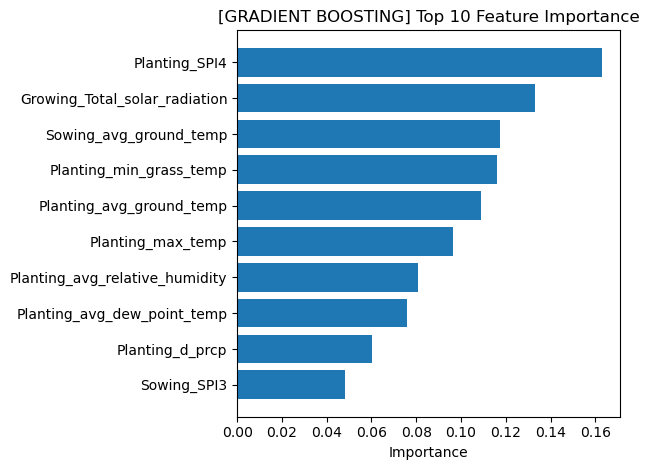


  [강릉] 2025년 출하일별 가격 변동 구간 예측 (RF  (N=10))
      date   정답  예측값    일치
2025-07-01 큰 하락 큰 하락  True
2025-07-02   하락 큰 하락 False
2025-07-03 큰 하락   상승 False
2025-07-04 큰 하락   상승 False
2025-07-05   상승   상승  True
2025-07-06   상승   상승  True
2025-07-07   하락   상승 False
2025-07-08 큰 하락   상승 False
2025-07-09   하락   상승 False
2025-07-10   상승   상승  True
2025-07-11   상승   상승  True
2025-07-12   상승   상승  True
2025-07-13   상승   상승  True
2025-07-14   상승   상승  True
2025-07-15   상승   상승  True
2025-07-16   상승   상승  True
2025-07-17   상승   상승  True
2025-07-18   상승   상승  True
2025-07-19   하락   상승 False
2025-07-20   상승   상승  True
2025-07-21   하락   상승 False
2025-07-22 큰 하락   상승 False
2025-07-23   하락   상승 False
2025-07-24 큰 하락   상승 False
2025-07-25   하락   상승 False
2025-07-26   상승   상승  True
2025-07-27   하락   상승 False
2025-07-28   하락   상승 False
2025-07-29   상승   상승  True
2025-07-30 큰 상승   상승 False
2025-07-31   상승   상승  True
2025-08-01   상승   상승  True
2025-08-02   상승   상승  True
2025-08-03   상승   상승  True
2025-08-04 

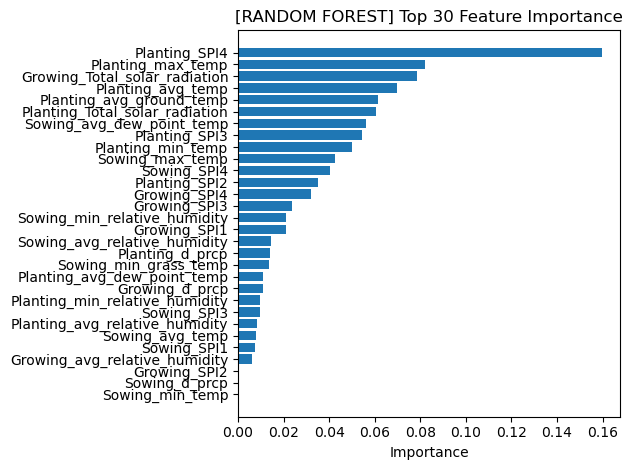

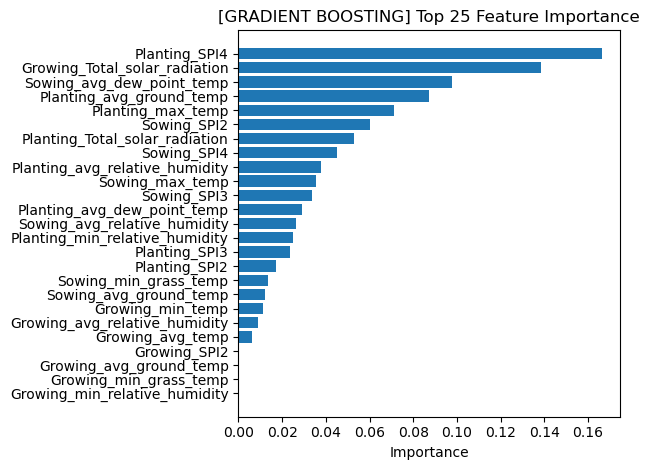


  [대관령] 2025년 출하일별 가격 변동 구간 예측 (RF  (N=30))
      date   정답  예측값    일치
2025-07-01 큰 하락   상승 False
2025-07-02   하락   상승 False
2025-07-03 큰 하락   상승 False
2025-07-04 큰 하락   상승 False
2025-07-05   상승   상승  True
2025-07-06   상승   상승  True
2025-07-07   하락   상승 False
2025-07-08 큰 하락   상승 False
2025-07-09   하락   상승 False
2025-07-10   상승   상승  True
2025-07-11   상승   상승  True
2025-07-12   상승   상승  True
2025-07-13   상승   상승  True
2025-07-14   상승   상승  True
2025-07-15   상승   상승  True
2025-07-16   상승   상승  True
2025-07-17   상승   상승  True
2025-07-18   상승   상승  True
2025-07-19   하락   상승 False
2025-07-20   상승   상승  True
2025-07-21   하락   상승 False
2025-07-22 큰 하락   상승 False
2025-07-23   하락   상승 False
2025-07-24 큰 하락   상승 False
2025-07-25   하락   상승 False
2025-07-26   상승   상승  True
2025-07-27   하락   상승 False
2025-07-28   하락   상승 False
2025-07-29   상승   상승  True
2025-07-30 큰 상승   상승 False
2025-07-31   상승   상승  True
2025-08-01   상승   상승  True
2025-08-02   상승   상승  True
2025-08-03   상승   상승  True
2025-08-04

Exception ignored in: <function ResourceTracker.__del__ at 0x104a91bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1036e9bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107951bc0>
Traceback (most recent call last

In [ ]:
for region in REGION_LIST:
      X_train, X_test, y_train, y_test = load_dataset(region)
      importance_df = importance_dfs[region]

      # 모델별 최적 N 찾기
      best_n_rf  = max(results[region], key=lambda n: results[region][n]['RF'])
      best_n_gb  = max(results[region], key=lambda n: results[region][n]['GB'])
      best_n_svm = max(results[region], key=lambda n: results[region][n]['SVM'])

      print(f"\n[{region}] 최적 N — RF: {best_n_rf}, GB: {best_n_gb}, SVM: {best_n_svm}")

      # RF — 최적 N 피처로 최종 학습
      rf_cols  = get_top_features(importance_df, 'RF', best_n_rf)
      final_rf = train_random_forest(X_train[rf_cols], y_train)

      # GB — 최적 N 피처로 최종 학습
      gb_cols  = get_top_features(importance_df, 'GB', best_n_gb)
      final_gb = train_gradient_boosting(X_train[gb_cols], y_train)

      # SVM — RF 피처 순위 공유
      # X_train_scaled = scaler.fit_transform(X_train)
      # X_test_scaled = scaler.transform(X_test)
      svm_cols = get_top_features(importance_df, 'RF', best_n_svm)
      X_train_scaled, _, svm_scaler = scale_for_svm(X_train[svm_cols], X_test[svm_cols])
      final_svm = train_svm(X_train_scaled, y_train)

      # Figure 재현
      plot_feature_importance(final_rf,  X_train[rf_cols],  "RANDOM FOREST",     top_n=best_n_rf)
      plot_feature_importance(final_gb,  X_train[gb_cols],  "GRADIENT BOOSTING", top_n=best_n_gb)

      # 2025년 예측 출력
      show_year_results(final_rf,  region, 2025, f"RF  (N={best_n_rf})",  feature_cols=rf_cols)
      show_year_results(final_gb,  region, 2025, f"GB  (N={best_n_gb})",  feature_cols=gb_cols)
      show_year_results(final_svm, region, 2025, f"SVM (N={best_n_svm})", feature_cols=svm_cols, scaler=svm_scaler)